<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">

## Generate SMILES molecules using Recurrent Neural Networks (RNN)

**Goal** Gain hands-on experience with `torch` in handling simple RNN and the generation process. 
    
This notebook applies RNNs to generate new SMILES string from the ZINC250k dataset of (canonized) strings. The network is trained on the data, and used autoregressively to actually generate new SMILES representations that are then assessed.
    
**The network will learn to 'speak' SMILES**

</div>    

<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">
    
**Training dataset**

* ~100,000 molecules represented by SMILES strings, from the 'ZINC250k` (curated) dataset of canonized strings (a curated drug-like subset of ZINC15, widely used in ML generative chemistry)
</div>

<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">
    
## Why an RNN?

Recurrent Neural Networks (RNNs, e.g. LSTMs, GRUs) were among the *first deep learning models* applied to molecular generation via SMILES.  
They demonstrated that molecules could be treated like sequences and generated character by character, much like natural language.

**Industry note:**  
Today, RNNs are largely replaced by **transformer-based models** (e.g. ChemBERTa, MolBERT, MegaMolBART) for SMILES, and by **graph transformers** or **diffusion models** for structure-aware generation.  

In this notebook, the RNN serves as a **didactic baseline**:
- It shows the *foundations* of molecular language modeling.  
- It provides an interpretable starting point before moving to more advanced models (transformers, diffusion).  
- It illustrates key evaluation metrics (validity, novelty, uniqueness, QED/logP distributions) that remain standard across modern generative approaches.

</div>

<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">

## Idea behind a vanilla RNN
    
The probability being learned in this RNN-based SMILES generator is $p(x_1, x_2, \ldots, x_T)$, aka the probability of the sequence $[x_1, x_2, \ldots, x_T]$, which can be factorized as:
$$p(x_1, x_2, \ldots, x_T) = \prod_t p(x_{t}|p_{<t})$$
where $p_{<t}$ is the prefix (the sequence of all tokens before $t$) and $x_t$ is the token at position $t$ of the SMILES string
    
    
An RNN processes sequences by maintaining a hiddens tate that is updated at each step. At time step $t$:
    $$h_t = f(W_{xh}x_t + W_{hh} h_{t-1} + b_h)$$
where $x_t$ is the input at step $t$ (here, token embedding), $h_{t-1}$ is the hidden state from the previous step, $W_{xh}, W_{hh}, b_h$ are learnable parameters and $f(\cdot)$ is the non-linear activation. 

The hidden state summarizes the **entire prefix** of the sequence up to that step
    
The model then produces logits for the next token through a linear projection $z_t = W_{hy}h_t + b_y$, where $z_t \in \mathbb{R}^V$, $V$ being the vocabulary size. Applying softmax gives the provablity distribution over the vocabulary.
$$P(x_{t+1} = v | x_{\leq t}) = \frac{\exp (z_{t,v})}{\sum_u^V \exp ( z_{t,u})}$$
    



**==== How the RNN learns it ==== **

During training, the RNN sees a sequence prefix  $p_{<t}$ and is asked to predict the next token $x_t$. The loss is typically the cross-entropy loss between the predicted distribution over tokens and the true next token. This is equivalent to maximizing the likelihood of the data under the model.

By training over many sequences, the model adjusts its weights so that it approximates the true conditional probabilities of tokens in valid SMILES.

**Note**
Please note we are not assuming strict Markovianity. Instead, we assume each new token depends on a **hidden state** that encodes the entire sequence so far. That’s why RNNs (and even more so Transformers) are generative sequence models rather than plain Markov chains.

</div>

In [39]:
import numpy as np, pandas as pd, os, math, random, time
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, QED

import matplotlib
%matplotlib inline

import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import random_split
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [38]:
pad_length = 120     # this will have to be tuned according to the SMILES that we have
print('Max length of input SMILES = ' + str(pad_length))


# NN TRAINING
train_fraction = 0.8
val_fraction = 0.1

batch_size = 128
print('Batch size = ' + str(batch_size))

n_epochs = 30
print('Number of training epochs = ' + str(n_epochs))

# SAMPLE GENERATION
temp = 0.85
print('Sampling temperature = ' + str(temp))

n_gen = 500
print('Number of samples to generate = ' + str(n_gen))

max_len = 120
print('Max length of generated SMILES = ' + str(max_len))

Max length of input SMILES = 120
Batch size = 128
Number of training epochs = 30
Sampling temperature = 0.85
Number of samples to generate = 500
Max length of generated SMILES = 120


<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Helper functions
    
</div>

In [ ]:
def define_tokens(smiles: str):
    
    """ Takes in a SMILES string and returns the tokenization = split string into tokens """
    
    tokens = []
    i = 0
    while i < len(smiles):
        # check two-character tokens
        if smiles[i:i+2] in ("Cl", "Br", "@@"):
            tokens.append(smiles[i:i+2])
            i += 2
        else:
            tokens.append(smiles[i])
            i += 1
    return tokens

def encode(smiles):
    
    """ Tokenization: from tokens to sequence of integers """
    
    tokens = ["<START>"] + define_tokens(smiles) + ["<END>"]
    unk_id = stoi["<UNK>"]
    return [stoi.get(t, unk_id) for t in tokens]

def decode(id_list):
    
    """ De-tokenization: from sequence of integers to tokens """   
    
    tokens = [itos[i] for i in id_list if itos[i] not in ("<PAD>", "<START>", "<END>")]
    return "".join(tokens)


def make_input_target(encoded):
    
    """
    Generate input and target sequences for next-token prediction.

    Given a sequence of token IDs, this function splits it into
    an input sequence (all tokens except the last) and a target
    sequence (all tokens except the first). This is typically used
    to prepare data for language modeling, where the model learns
    to predict the next token.

    Parameters:
        encoded (list[int] or np.ndarray): A sequence of encoded tokens.

    Returns:
        tuple:
            - inp (list[int] or np.ndarray): Sequence without the last token.
            - tgt (list[int] or np.ndarray): Sequence without the first token.
    """
    
    inp = encoded[:-1]
    tgt = encoded[1:]
    return inp, tgt

def pad_sequence(encoded_sequences, padded_length = None):
    
    """
    Pad a batch of encoded sequences to a common length.

    Each sequence is right-padded with the global ``pad_id`` token until
    they all reach the same length. The batch is returned as a NumPy array
    of shape ``(batch_size, padded_length)``.

    Parameters
    ----------
    encoded_sequences : list of list of int
        A list of tokenized sequences, where each sequence is a list of token IDs.
    padded_length : int, optional
        Desired padded length. If None (default), the length of the longest
        sequence in the batch is used.

    Returns
    -------
    np.ndarray
        Array of shape ``(batch_size, padded_length)`` containing padded sequences,
        with dtype int64.
    """
    
    all_padded = []

    if padded_length is None:
        padded_length = max(len(seq) for seq in encoded_sequences)
    
    for seq in encoded_sequences:
        
        added_pads = padded_length - len(seq)
        seq = seq + list(np.ones(added_pads) * pad_id)
        all_padded.append(seq)
        
    return np.array(all_padded, dtype=np.int64)

In [ ]:
def run_epoch(loader, train=True, clip=1.0):
    model.train(train)
    total_loss, total_tokens = 0.0, 0
    
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            optimizer.zero_grad()
        pred = model(xb)                            # (B,T,V)
        labels = yb.reshape(-1)
        
                         # predictions from the NN        # actual target from the data to compare against
        loss = loss_fn(pred.reshape(-1, V), labels)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            
        # count non-PAD targets for averaging
        ntok = (yb != pad_id).sum().item()
        total_loss += loss.item() * max(ntok, 1)
        total_tokens += max(ntok, 1)
    return total_loss / total_tokens      # this ensures fair averaging per token, regarless of seqeucne length.
                                          # wthout this, the reported loss would be biased toward short or long SMILES


<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Curate SMILES dataset: load and canonize
    
We canonicalized all SMILES using RDKit and verified that no duplicates were removed, confirming the dataset was already distributed in canonical form. This step ensures that train/val/test splits are made on unique molecules, eliminating potential data leakage. Here, the dataset is alredy canonicalized, and all molecules are truly different from one another
    
</div>

In [34]:
datafile = '250k_rndm_zinc_drugs_clean_3.csv'

input_data = os.path.join('data', datafile)

# Load CSV
df = pd.read_csv(input_data)
print(df.columns)    # printing the head
      
# Grab 'smiles' column
smiles_list = df["smiles"].dropna().tolist()

# Quick validity check with RDKit
valid_smiles = []
for s in smiles_list:
    mol = Chem.MolFromSmiles(s)
    if mol is not None:
        valid_smiles.append(Chem.MolToSmiles(mol, canonical=True))     # make sure there are no duplicates

print(f"We now select the first 100,000 valid SMILES molecules, to be used for training")
random.shuffle(valid_smiles)
subset = valid_smiles[:100000]

Index(['smiles', 'logP', 'qed', 'SAS'], dtype='object')
We now select the first 100,000 valid SMILES molecules, to be used for training


Text(0.5, 1.0, 'Histogram for the training subset')

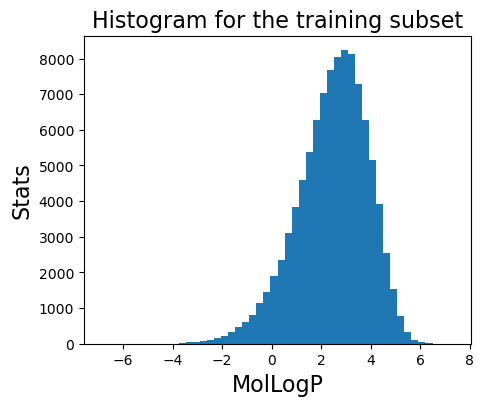

In [30]:
fig = plt.figure(figsize = (5,4))

# choose between LogP or molecular weight
logps = [Descriptors.MolLogP(Chem.MolFromSmiles(s)) for s in subset]
#mw = [Descriptors.MolWt(Chem.MolFromSmiles(s)) for s in subset]

plt.hist(logps, bins = 50)
plt.xlabel('MolLogP', fontsize = 16)
plt.ylabel('Stats', fontsize = 16)
plt.title('Histogram for the training subset', fontsize = 16)

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Define tokens, encoding and decoding functions 
    
Converts SMILES strings into sequences of tokens that can be mapped to integers and fed into the RNN
Without tokenization, the model cannot learn the sequential grammar of SMILES
    
</div>

In [35]:
# --- User-defined SMILES vocabulary/alphabet: ideally, one could build this from analyzing the strings ---

VOCAB = [
    # Special tokens [padding, start, end, unknown symbol]
    "<PAD>", "<START>", "<END>", "<UNK>",

    # Common atoms
    "C", "O", "N", "S", "P", "F", "Cl", "Br", "I",

    # Aromatic atoms (lowercase form often used in SMILES)
    "c", "o", "n", "s", "p",

    # Bonds
    "-", "=", "#",

    # Branching / rings
    "(", ")", "[", "]",

    # Ring closure digits
    "1","2","3","4","5","6","7","8","9",
    
    # Stereo / charges
    "@", "@@", "+", "H"
]


# Build dictionaries: use increasing integer numbers for tokenization
stoi = {tok: i for i, tok in enumerate(VOCAB)}   # from tokens to integers
itos = {i: tok for tok, i in stoi.items()}     # from integers to tokens

V        = len(stoi)    # dictionary size
print('Dictionary length for tokenization = ' + str(V))

Dictionary length for tokenization = 38


In [33]:
# testing the tokenization/encoding/decoding process
test_smile = "CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1"
#test_smile = "C@@H"
print(f'Testing encoding and decoding for test SMILES {test_smile}')
# test
s = define_tokens(test_smile)
enc = encode(s)
print(f'Encoded representation = {enc}')
s_back = decode(enc)
print(f'Decodes representaton = {s_back}')
assert s_back == test_smile

Testing encoding and decoding for test SMILES CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1
Encoded representation = [1, 4, 4, 21, 4, 22, 21, 4, 22, 13, 25, 13, 13, 13, 26, 14, 13, 13, 21, 4, 4, 21, 19, 5, 22, 6, 13, 27, 13, 13, 13, 13, 13, 27, 9, 22, 13, 26, 13, 25, 2]
Decodes representaton = CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1


<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Upon tokenization, define input, output and pad them

</div>

As for input, output: the output is the token following the previous ones.

Neural nets (and GPUs) like rectangular tensors: every batch must have the same shape (batch_size, max_len).
But molecules have different lengths, so we need to pad shorter sequences with a dummy token (<PAD>).

`<START> 1 3 5 7 <END>` padded to `<START> 1 3 5 7 <END> <PAD> <PAD> <PAD>`

In [10]:
inputs = []
target = []

# integer corresponding to the padding entry
pad_id = stoi["<PAD>"]

print('Prepare input nd output arrays')
#test_smiles = ["CCO", "CC(=O)O", "HCl"]
for smile in subset:

    #print(encode(smile))
    inp, tgt = make_input_target(encode(smile))    
    inputs.append(inp)
    target.append(tgt)

assert len(inputs[0]) == len(target[0])

In [11]:
print('Pad both input and inputs')
A = pad_sequence(inputs, pad_length)    #100
B = pad_sequence(target, pad_length)    #100

print(A.shape, B.shape)

(100000, 120) (100000, 120)


<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### convert dataset to `torch` tensor, define `DataLoader` objects for train, validation and test
(I have previously used `DataLoader` and `Data` from `PyG`, but those were specifically for graph objects (see GNN project)

</div>

In [12]:
# convert to torch
x = torch.from_numpy(A).long()
y = torch.from_numpy(B).long()
dataset = TensorDataset(x, y)
N = len(dataset)


n_train = int(train_fraction * N)
n_val   = int(val_fraction * N)
n_test  = N - n_train - n_val

print(f"train={n_train}, val={n_val}, test={n_test}")
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test],generator=torch.Generator().manual_seed(42))  # reproducible split


# data loader
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size)
test_loader  = DataLoader(test_ds, batch_size=batch_size)

print(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

train=80000, val=10000, test=10000
80000 10000 10000


<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

### Define the model architecture
    
We use a Gated Recurrent Unit (GRU) instead of a simple RNN because its gating mechanism helps retain long-range information and mitigates vanishing gradients, which is crucial for learning valid SMILES sequences.
    
Here, long range refers to both closing rings or branches, whihc may depend on tokes seen much earlier

</div>

<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">
  

SmilesGRU is essentially a next-token predictor for SMILES. It learns embeddings, processes them sequentially with GRU memory, and classifies each step over the vocabulary

**embedding layer** essentially it is a trainable token to vector dctionary; similar to a `Linear` layer, with some features that are well-suited for tokens like SMILES symbols
One could one-hot encode the token and apply a linear layer to project to `emb_dim`, that would be equivalent. But `embedding` is much more efficient

Learns distributed representations of tokens, so chemically similar tokes may get similar embeddings

The embedding layer does not produce one single vector for the whole SMILES, it produces a sequence of vectors (one per token) so that the GRU can process them step-by-step, mantaining order

The GRU threads them together across time, carrying memory in the hidden state. The linear projection maps that memory to “which token comes next?”

</div>

In [13]:
class SmilesGRU(nn.Module):
    def __init__(self, vocab_size, pad_id=0, emb_dim=128, hidden_dim=256, num_layers=1, dropout=0.0, use_lstm=False, tie_weights=True):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)     #embedding layer, pad_id ignored during training
                                                                               # turn each token ID (int) into a dense vector of size `emb_dim`
        rnn_cls = nn.LSTM if use_lstm else nn.GRU     # process the sequence step by step
        self.rnn = rnn_cls(       # this is the actual RNN that will process the sequences of tokens at each time step
            emb_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.proj = nn.Linear(hidden_dim, vocab_size, bias=True)
        
        if tie_weights:
            assert emb_dim == hidden_dim  # "Weight tying requires emb_dim == hidden_dim"
            self.proj.weight = self.embed.weight  # share parameters

    def forward(self, x, h0=None):
        e = self.embed(x)         # (B, T, E)
        y, h = self.rnn(e, h0)    # (B, T, H)     # hidden states are returned together with outputs, if None, then all 0s
        logits = self.proj(y)    # takes the hidden state at each position (B, T, H) and map to (B, T, V), map to dictionary length
                                                                  # this is the actual multi-classification HEAD: at each time, predict next token
        return logits     # one normalized score per vocab token, ready for cross-entropy

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

### Instantiate model and train it using training and validation datasets
</div>

In [14]:
pad_id = stoi["<PAD>"]   # 0 in your setup

model = SmilesGRU(
    vocab_size=V,
    pad_id=pad_id,
    emb_dim=128,
    hidden_dim=128,       # 128 here to allow weight tying (emb=hidden), hidden state
    num_layers=1,
    dropout=0.0,
    use_lstm=False,
    tie_weights=True
).to(device)

print(model)

# define loss and optimizer
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)     # ignore padding for padded encoded SMILES tensors
optimizer = optim.Adam(model.parameters(), lr=2e-3)


train_losses, val_losses = [], []

best_val = float("inf")
for epoch in range(1, n_epochs):  # start with ~5 epochs; adjust after you see curves
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)

    train_losses.append(tr)
    val_losses.append(va)
    
    print(f"epoch {epoch} | train CE {tr:.4f} | val CE {va:.4f} | ppl {math.exp(va):.2f}")
    if va < best_val - 1e-4:
        best_val = va
        torch.save(model.state_dict(), os.join.folder('results', "smiles_gru.pt"))


Vocabulary size (number of letters, tokens) = 38
SmilesGRU(
  (embed): Embedding(38, 128, padding_idx=0)
  (rnn): GRU(128, 128, batch_first=True)
  (proj): Linear(in_features=128, out_features=38, bias=True)
)
epoch 1 | train CE 0.9762 | val CE 0.8150 | ppl 2.26
epoch 2 | train CE 0.7804 | val CE 0.7622 | ppl 2.14
epoch 3 | train CE 0.7395 | val CE 0.7256 | ppl 2.07
epoch 4 | train CE 0.7157 | val CE 0.7078 | ppl 2.03
epoch 5 | train CE 0.7008 | val CE 0.6980 | ppl 2.01
epoch 6 | train CE 0.6884 | val CE 0.6919 | ppl 2.00
epoch 7 | train CE 0.6797 | val CE 0.6814 | ppl 1.98
epoch 8 | train CE 0.6726 | val CE 0.6809 | ppl 1.98
epoch 9 | train CE 0.6662 | val CE 0.6683 | ppl 1.95
epoch 10 | train CE 0.6617 | val CE 0.6667 | ppl 1.95
epoch 11 | train CE 0.6568 | val CE 0.6631 | ppl 1.94
epoch 12 | train CE 0.6529 | val CE 0.6617 | ppl 1.94
epoch 13 | train CE 0.6495 | val CE 0.6560 | ppl 1.93
epoch 14 | train CE 0.6460 | val CE 0.6520 | ppl 1.92
epoch 15 | train CE 0.6432 | val CE 0.6569 

In [ ]:
# load model (if pre-trained)
model.load_state_dict(torch.load(os.join.folder('results', "smiles_gru.pt"), map_location=device))
model.eval()

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Assess model on test_test, compute perplexity
    
</div>

In [15]:
model.eval()

loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)      # ignore "padding" tokens
total_loss, total_tokens = 0.0, 0

# disable gradien tracking, we don't need it
with torch.no_grad():
    for xb, yb in test_loader:  # from earlier splitting
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)  # (B, T, V)
        loss = loss_fn(pred.view(-1, vocab_size), yb.view(-1))     # view/reshape

        ntok = (yb != pad_id).sum().item()      # .item(), extracts one single scalar number from the tnesor
        total_loss += loss.item() * ntok
        total_tokens += ntok

test_loss = total_loss / total_tokens
test_ppl = math.exp(test_loss)

print(f"Test CE: {test_loss:.4f} | Test Perplexity: {test_ppl:.2f}")

Test CE: 0.6334 | Test Perplexity: 1.88


<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Use the network to generate new samples via autoregressive generation
    
</div>

<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">

**Autoregressive generation:**
- Start with the special `<START>` token
- At each step $t$:
   - The model outputs logits $z$ for all tokens, based on the **entire prefix** (captured in the hidden state)
   - Apply softmax on the logits to obtain a probability distribution over the vocabulary:
     $$P(x_t = v | x_{<t}) = \frac{\exp (\beta z_v)}{\sum_u \exp (\beta z_u)}, \qquad \beta = T^{-1}$$
  where $z_v$ are the logits and $T$ is the sampling temperature 
- Sample the next token from this distribution
- Append it to the sequence and feed it back into the model
- Stop whe `<END>` is generated or a maximum length is reached
- Check SMILES validity/novelty (via RDKit)

**Notes**
- The process samples from the full distribution $p(x_1, x_2, \ldots, x_T)$
- Conditioning is not just Markovian - each new token depends on the entire history, ot only the last symbol
- Temperature controls diversity
- Sampling rather than greedy decoding allows the model to generate diverse molecules instead of producing the same string all over again

In [36]:
@torch.no_grad()
def sample_one_SMILE(max_len=120, temperature=temp, top_k=30):     # 120 is the pad length

    """
    Generate a single SMILES string from the trained RNN model.

    Starting with a <START> token, the model repeatedly predicts the probability
    distribution of the next token conditioned on all tokens generated so far.
    At each step:
      1. The prefix (list of token IDs generated so far) is passed through the model to obtain logits for the last position.
      2. Logits are scaled by `temperature` to control distribution sharpness
         (T < 1.0 → sharper/more greedy, T > 1.0 → flatter/more random).
      3. If `top_k` is set, restricts sampling to the top-k most probable tokens (optional)
      4. A token ID is sampled from the resulting categorical distribution and appended.

    The loop terminates when either:
      - The <END> token is generated, or
      - The sequence reaches `max_len` tokens.

    This approach is known as autoregressive sampling
    
    Args:
        max_len (int): Maximum number of tokens to generate before stopping.
        temperature (float): Sampling temperature; controls randomness of token selection.
        top_k (int or None): If set, sample only from the top-k most probable tokens.

    Returns:
        str: A SMILES string generated by the model (without <START>/<END>/<PAD> tokens).
    """
    
    model.eval()
    ids = [stoi["<START>"]]    # begin list with <START>
    for _ in range(max_len):

        # define the prefix (= tokenized string generated so far)
        x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)  # (1,t)

        # extract network output at the last step
        logits = model(x)[:, -1, :]  # last step, shape (1t)   # this s the learned distribution before softmax
        logits = logits / max(1e-6, temperature)    # scale logits by a termperature to control sampling

        # Top-k filtering
        if top_k is not None:
            k = min(top_k, V)
            vals, idxs = torch.topk(logits, k=k, dim=-1)     # restrict to the top-k most likely tokens
            probs = F.softmax(vals, dim=-1)    # probabilities that sum to 1
            next_id = idxs[0, torch.multinomial(probs, 1)].item()
        else:
            probs = F.softmax(logits, dim=-1)       # build the distribution
            next_id = torch.multinomial(probs, 1).item()       # sample from the distribution

        ids.append(next_id)
        if next_id == stoi["<END>"]:     # if <END>, stop; otherwise, feed the updates `ids` back into the GRU for the next step
            break

    return decode(ids)

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Actively generate molecules and look at evaluation matrices
    
Our simple GEU baseline archives ~76% validity, confirming that the model captures most SMILES grammar rules but still struggles with long-range dependencies (e.g., ring closures, stereochemistry)

Generated valid molecules were 100% unique, indicating the model explores chemical space rather than memorizing training examples, and 100% novel, indicating the model goes beyond the training set
</div>

In [ ]:
def is_valid_smiles(s: str) -> bool:
    return s != "" and (Chem.MolFromSmiles(s) is not None)

def canon(s):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, canonical=True) if m else None


# generate
a = time.time()

samples = [sample_one_SMILE(max_len=max_len, temperature=temp, top_k=30) for _ in range(n_gen)]
b = time.time()
print(f'Time needed to generate {n_gen} SMILES of length {max_len} = {b-a} s')

# Metrics
valid = [s for s in samples if is_valid_smiles(s)]
validity   = len(valid) / max(1, len(samples))
uniqueness = len(set(valid)) / max(1, len(valid))

In [19]:
train_smiles = [subset[i] for i in train_ds.indices]

train_set = {canon(s) for s in train_smiles if canon(s)}
gen_valid_canon = {canon(s) for s in valid if canon(s)}

novel = [s for s in valid if canon(s) not in train_set]
novelty = len(novel) / max(1, len(valid))
print(f"Novelty (canonical): {novelty:.2%}")

print(f"Novelty:    {novelty:.2%} (if train_set available)")
print(f"Validity:   {validity:.2%}")
print(f"Uniqueness: {uniqueness:.2%}")

80000
Novelty (canonical): 100.00%
Novelty:    100.00% (if train_set available)
Generated: 500
Validity:   76.80%
Uniqueness: 100.00%


In [40]:
# save the new samples to a file
np.savez_compressed('generated_SMILES.npz', samples = samples)

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Visualize some generated molecules, label them by logP and QED
    
</div>

In [25]:
# select just a few molecules to plot
selected_valid_samples = [s for q, s in enumerate(valid) if q in range(0, 500, 50)]

mol_list = [Chem.MolFromSmiles(smi) for smi in selected_valid_samples]

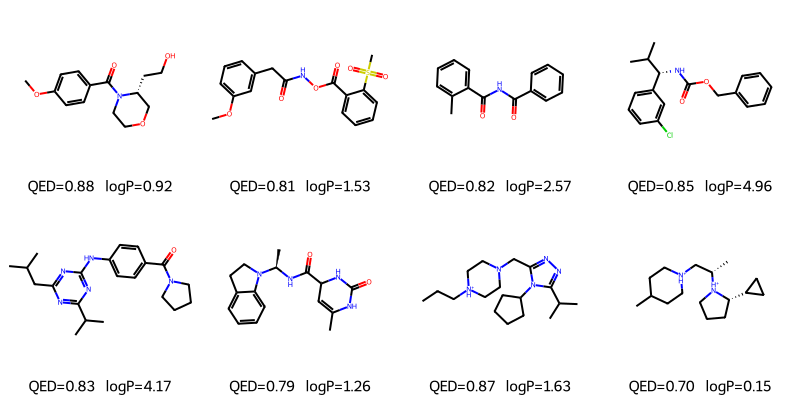

<Figure size 640x480 with 0 Axes>

In [41]:
# Quantitative-Estimate of Drug-likeness (QED), a single score in [0,1]
                                                 # that combines multiple descriptors in a drug-likeness measure
legends = []
for s in mol_list:
    legends.append(f"QED={QED.qed(s):.2f}  logP={Descriptors.MolLogP(s):.2f}")
    
img = Draw.MolsToGridImage(mol_list, molsPerRow=4, subImgSize=(200, 200), legends = legends)
display(img)


In [ ]:
# one could histogram a bunch of properties of the generated props, extract them from Chem.Descriptors

<div style="background-color: lightyellow; padding: 10px; border-radius: 5px;">
    
## Outlook: towards Transformers
    
**Why RNNs struggle with sequences**
Recurrent neural networks (RNNs), including LSTMs and GRUs, process sequences token by token, updating a hidden state that carries information from the past. While this makes them naturally suited for ordered data like SMILES strings, it also creates two limitations. 
- First, RNNs are inherently sequential: each step depends on the previous one, so they cannot be fully parallelized during training, which slows them down on large datasets.
- Second, all context must be squeezed through a single evolving hidden state, which makes it hard for the model to capture long-range dependencies (e.g., an opening parenthesis and its matching closure many tokens later).
These bottlenecks often lead to vanishing gradients and degraded performance on long sequences.

**Why Transformers are better**
Transformers replace recurrence with self-attention, a mechanism where each token can directly “look at” every other token in the sequence. This change brings two decisive advantages:
- Transformers can process all tokens in parallel, massively speeding up training and making them more scalable;
- they handle long-range context naturally, since attention allows even distant tokens to interact without being compressed into a single hidden state.
In practice, this makes Transformers the dominant architecture for modern sequence modeling tasks, from natural language to molecular SMILES generation.

</div>